In [1]:
import pandas as pd
# Features utilisateurs + clusters
df_users = pd.read_csv("../data/processed/user_behavior_features.csv")

# Interactions utilisateur-produit
df_reviews = pd.read_csv("../data/processed/amazon_reviews_cleaned.csv")

df_users.columns



Index(['user_id', 'nb_interactions', 'recency_days', 'nb_products',
       'category_entropy', 'avg_rating', 'rating_std', 'avg_review_length',
       'avg_sentiment', 'weekend_activity_ratio'],
      dtype='object')

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Séparer l'identifiant
user_ids = df_users["user_id"]

# Features numériques pour le clustering
X = df_users.drop(columns=["user_id"])


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


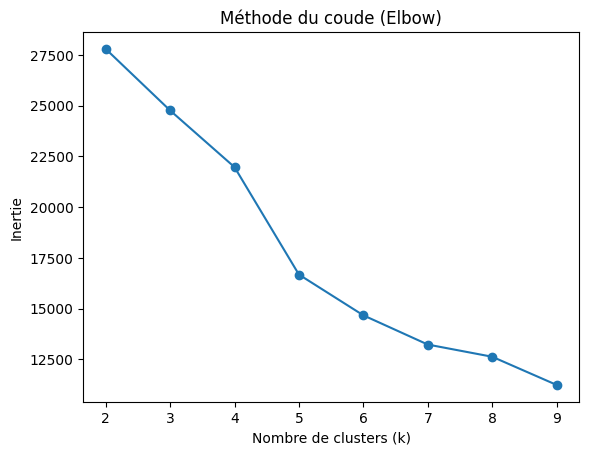

In [4]:
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude (Elbow)")
plt.show()


In [5]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)

clusters = kmeans.fit_predict(X_scaled)


In [6]:
df_users["cluster"] = clusters


In [7]:
df_users.head()
df_users["cluster"].value_counts()


cluster
1    1935
2     817
3     700
0     319
4       6
Name: count, dtype: int64

In [8]:
valid_clusters = df_users[df_users["cluster"] != 4]


In [10]:
df_users.head()

,user_id,nb_interactions,recency_days,nb_products,category_entropy,avg_rating,rating_std,avg_review_length,avg_sentiment,weekend_activity_ratio,cluster
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1,1840,1,-0.0,0.557747,0.000000,17.000000,0.416667,1.000000,3
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,1,4840,1,-0.0,0.557747,0.000000,59.000000,0.251389,0.000000,1
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,2,1,2,-0.0,0.557747,0.000000,40.500000,0.240655,0.000000,1
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,9,1219,9,-0.0,0.158272,1.198424,9.333333,0.439947,0.333333,2
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,3,596,3,-0.0,-0.041465,0.518933,18.666667,0.184028,0.000000,1


In [11]:
df_users.to_csv(
    "../data/processed/user_behavior_features_with_clusters.csv",
    index=False
)


In [13]:
df_users_cluster = pd.read_csv(
    "../data/processed/user_behavior_features_with_clusters.csv"
)

In [15]:
df_reviews_clustered = df_reviews.merge(
    df_users[["user_id", "cluster"]],
    on="user_id",
    how="left"
)

# Exclure les outliers (cluster 4)
df_reviews_clustered = df_reviews_clustered[
    df_reviews_clustered["cluster"] != 4
]


In [16]:
cluster_product_popularity = (
    df_reviews_clustered
    .groupby(["cluster", "parent_asin"])
    .size()
    .reset_index(name="nb_interactions")
)


In [17]:
def recommend_by_cluster(user_id, n=5):
    # cluster de l'utilisateur
    user_cluster = df_users.loc[
        df_users["user_id"] == user_id, "cluster"
    ].values[0]
    
    # si outlier → fallback popularité globale
    if user_cluster == 4:
        return []
    
    # produits déjà vus
    seen_items = set(
        df_reviews_clustered[
            df_reviews_clustered["user_id"] == user_id
        ]["parent_asin"]
    )
    
    # candidats du cluster
    candidates = (
        cluster_product_popularity[
            cluster_product_popularity["cluster"] == user_cluster
        ]
        .sort_values("nb_interactions", ascending=False)
        ["parent_asin"]
        .tolist()
    )
    
    # filtrage
    recommendations = [
        item for item in candidates if item not in seen_items
    ]
    
    return recommendations[:n]


In [18]:
test_user = df_users[df_users["cluster"] != 4]["user_id"].iloc[0]
recommend_by_cluster(test_user, n=5)


['B014QI0FI8', 'B0002BNX7E', 'B0009PUCUE', 'B0002JW70A', 'B0057P6TZ8']

In [19]:
cluster_product_popularity[
    cluster_product_popularity["parent_asin"].isin([
        'B014QI0FI8', 'B0002BNX7E', 'B0009PUCUE', 'B0002JW70A', 'B0057P6TZ8'
    ])
].sort_values("nb_interactions", ascending=False)


,cluster,parent_asin,nb_interactions
2518,1,B014QI0FI8,4
15564,3,B0002BNX7E,3
15579,3,B0009PUCUE,3
16105,3,B014QI0FI8,3
1016,1,B0009PUCUE,2
15568,3,B0002JW70A,2
15846,3,B0057P6TZ8,2
937,1,B0002JW70A,1


In [21]:
recommended_asins = [
    'B014QI0FI8', 'B0002BNX7E', 'B0009PUCUE', 'B0002JW70A', 'B0057P6TZ8'
]

df_reviews[
    df_reviews["parent_asin"].isin(recommended_asins)
][["parent_asin", "title", "category"]].drop_duplicates()


,parent_asin,title,category
12107,B0057P6TZ8,great variety of tunes,Digital_Music
12198,B0057P6TZ8,Nice variety and quality of sound,Digital_Music
12366,B014QI0FI8,Love the Band,Digital_Music
12484,B014QI0FI8,As expected,Digital_Music
12694,B0002JW70A,: ¦: -•: *: •. ...,Digital_Music
13123,B014QI0FI8,GREAT CD !!!,Digital_Music
13465,B0002BNX7E,All time best,Digital_Music
13490,B0002BNX7E,awesome,Digital_Music
13498,B0009PUCUE,Five Stars,Digital_Music
13794,B0009PUCUE,Bout for a gift,Digital_Music


In [22]:
# Le choix de k=5 segmente les comportements, mais le petit cluster 4 (6 utilisateurs) a été exclu comme outlier, ce qui évite des recommandations instables pour ces profils
# Les résultats sont dominés par Digital_Music

In [23]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} → silhouette={score:.3f}")

k=2 → silhouette=0.320
k=3 → silhouette=0.324
k=4 → silhouette=0.286
k=5 → silhouette=0.297
k=6 → silhouette=0.305
k=7 → silhouette=0.248


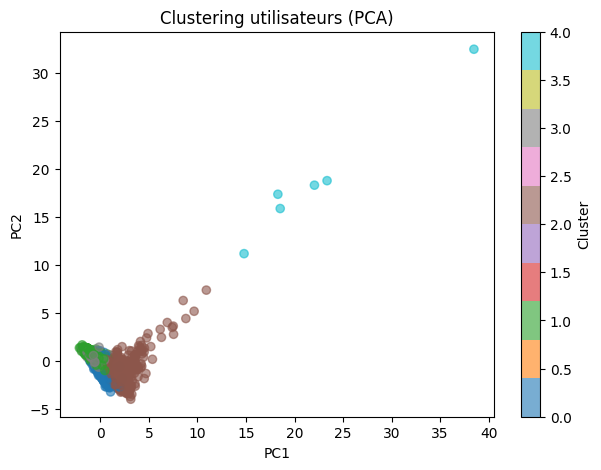

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_users_cluster["cluster"],
    cmap="tab10",
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering utilisateurs (PCA)")
plt.colorbar(label="Cluster")
plt.show()

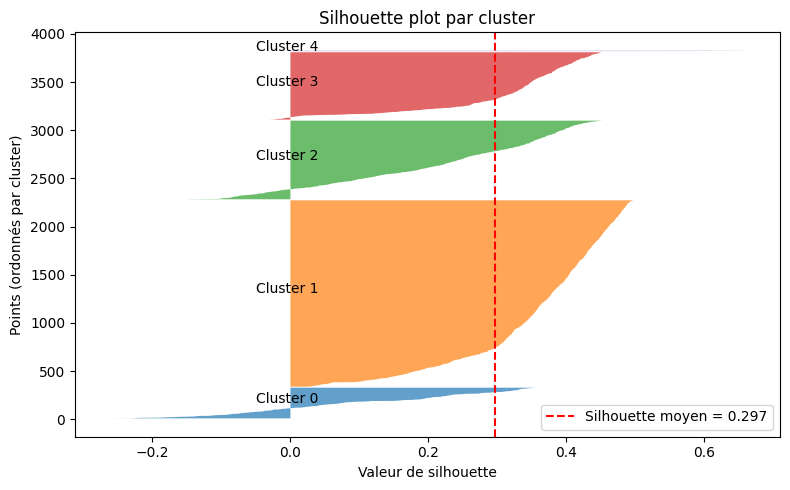

In [31]:
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score

X = X_scaled
labels = df_users_cluster["cluster"].values
sil_vals = silhouette_samples(X, labels)
sil_avg = silhouette_score(X, labels)

plt.figure(figsize=(8, 5))
y_lower = 10
for c in sorted(np.unique(labels)):
    c_sil_vals = sil_vals[labels == c]
    c_sil_vals.sort()
    size_c = c_sil_vals.shape[0]
    y_upper = y_lower + size_c
    color = plt.cm.tab10(c % 10)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil_vals, facecolor=color, alpha=0.7)
    plt.text(-0.05, (y_lower + y_upper) / 2, f"Cluster {c}")
    y_lower = y_upper + 10  # gap

plt.axvline(sil_avg, color="red", linestyle="--", label=f"Silhouette moyen = {sil_avg:.3f}")
plt.xlabel("Valeur de silhouette")
plt.ylabel("Points (ordonnés par cluster)")
plt.title("Silhouette plot par cluster")
plt.legend()
plt.tight_layout()
plt.show()

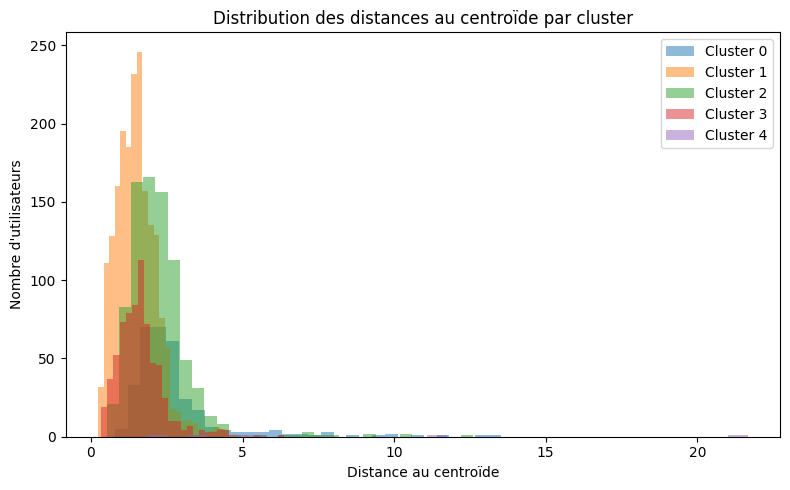

                           user_id  cluster  dist_to_centroid
1885  AFZUK3MTBIBEDQOPAK3OATUOUKLA        4         21.657245
1745  AFUZG4S57VOZIENQ5LJHBPEO5T2Q        0         13.524699
350   AEGVEWWGTQO3PK3JF5NYB7GSSSVQ        0         12.706226
1679  AFSKPY37N3C43SOI5IEXEK5JSIYA        2         12.612543
3424  AHOHZTCL3LM46MJ22CF5IXBFHKEA        0         11.791020
1406  AFJBKPK5W56XWSNPQU2WW66ISWYQ        4         11.712994
2325  AGJGO3CDKAJQUESHDTGB46WPKHCA        0         10.880499
1228  AFDMZ4TRX3HXQQUGWAHJQTIF65BQ        2         10.213824
3298  AHJQPUQLSQZE6LMIUMY7WNRXCQQQ        2         10.210854
1893  AG2LKLOEC5D7YP6VJNWU3IIIHERA        0          9.978623


In [33]:
# filename: distance_to_centroids.py

from sklearn.metrics import pairwise_distances_argmin_min

# Réutiliser le modèle KMeans déjà fit (kmeans)
centroids = kmeans.cluster_centers_
closest, distances = pairwise_distances_argmin_min(X_scaled, centroids)

df_users_cluster["dist_to_centroid"] = distances

plt.figure(figsize=(8,5))
for c in sorted(df_users_cluster["cluster"].unique()):
    d = df_users_cluster.loc[df_users_cluster["cluster"] == c, "dist_to_centroid"]
    plt.hist(d, bins=30, alpha=0.5, label=f"Cluster {c}")
plt.xlabel("Distance au centroïde")
plt.ylabel("Nombre d'utilisateurs")
plt.title("Distribution des distances au centroïde par cluster")
plt.legend()
plt.tight_layout()
plt.show()

# Quelques outliers potentiels
print(df_users_cluster.sort_values("dist_to_centroid", ascending=False).head(10)[["user_id","cluster","dist_to_centroid"]])


In [35]:
# filename: extra_indices.py
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

labels = df_users_cluster["cluster"].values
dbi = davies_bouldin_score(X_scaled, labels)  # plus petit = meilleur
ch = calinski_harabasz_score(X_scaled, labels)  # plus grand = meilleur

print(f"Davies-Bouldin Index: {dbi:.3f}")
print(f"Calinski-Harabasz Score: {ch:.1f}")

Davies-Bouldin Index: 1.135
Calinski-Harabasz Score: 978.8


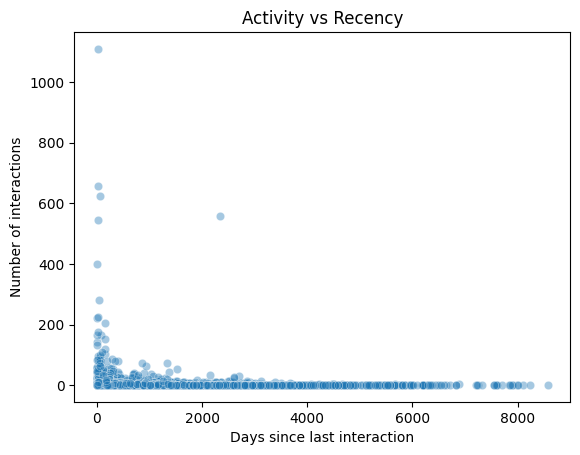

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df_users_cluster,
    x="recency_days",
    y="nb_interactions",
    alpha=0.4
)
plt.title("Activity vs Recency")
plt.xlabel("Days since last interaction")
plt.ylabel("Number of interactions")
plt.show()

In [40]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

df_users_cluster = pd.read_csv(
    "../data/processed/user_behavior_features_with_clusters.csv"
)

X = df_users_cluster.drop(columns=["user_id"])
X_scaled = StandardScaler().fit_transform(X)

In [41]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df_users_cluster["cluster_dbscan"] = dbscan.fit_predict(X_scaled)


In [42]:
df_users_cluster["cluster_dbscan"].value_counts()


cluster_dbscan
 0    3680
-1      97
Name: count, dtype: int64

In [43]:
for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    print(f"eps={eps} → clusters:", pd.Series(labels).value_counts().to_dict())


eps=0.8 → clusters: {1: 1621, -1: 718, 0: 501, 4: 378, 9: 125, 2: 78, 10: 57, 3: 56, 7: 47, 11: 18, 14: 18, 5: 17, 8: 16, 12: 14, 15: 12, 16: 11, 6: 11, 24: 10, 26: 8, 13: 7, 20: 7, 23: 7, 25: 6, 18: 6, 21: 6, 27: 6, 17: 5, 22: 5, 19: 4, 28: 2}
eps=1.0 → clusters: {1: 1883, 2: 635, 0: 534, -1: 381, 8: 66, 3: 60, 6: 55, 9: 37, 10: 21, 4: 19, 11: 18, 7: 16, 5: 14, 14: 8, 17: 8, 13: 6, 16: 6, 12: 5, 15: 5}
eps=1.2 → clusters: {0: 3489, -1: 205, 1: 44, 2: 11, 3: 9, 5: 9, 4: 5, 6: 5}
eps=1.5 → clusters: {0: 3680, -1: 97}
eps=2.0 → clusters: {0: 3738, -1: 39}
